# **Credit card fraud detection**
## Team members: Tim Harris & Trinh Tran
## Professor: Diala Ezzeddine

# Problem framing
Financial institutions need to reliably identify fraudulent credit card transactions to prevent
monetary loss and protect customers. The Credit Card Fraud Detection dataset from Kaggle
contains 284,807 real credit card transactions collected over two days, of which only 492
are labeled as fraudulent, making the dataset highly imbalanced. The dataset includes
anonymized numerical features obtained via Principal Component Analysis (PCA), along
with the original Time and Amount features, and a binary target label indicating whether a
transaction is fraudulent (Class = 1) or not (Class = 0).


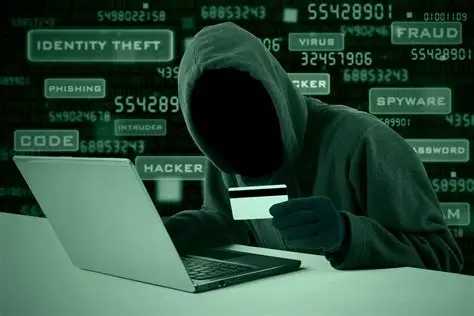

The goal is to design a system that accurately categorizes transactions to protect the bank's
assets while ensuring that 99.9% of honest customers never even notice the system is
running. We are looking for the case where we catch the most thieves while bothering the
fewest customers.

To solve this, we must:
- Detect and classify transactions as either fraudulent or legitimate despite the
extreme class imbalance.
- Mitigate the impact of skewed class distribution by applying techniques like
resampling, class weighting, or algorithmic modifications.
- Evaluate model performance using metrics appropriate for imbalanced
classification.

This problem is formulated as a binary classification task where the model should learn patterns that distinguish genuine transactions from fraudulent ones based on the provided features. This is important because fraudulent transactions are rare but costly, class imbalance makes detection challenging, and accurate models are essential to minimize financial loss while avoiding unnecessary disruption to legitimate customers.

# Data loading and exploration

## Get the data

In [ ]:
import pandas as pd

In [ ]:
url = "https://huggingface.co/datasets/tnltrinh/credit_card_fraud/resolve/main/dataset/creditcard.csv"
df = pd.read_csv(url)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

All columns are numeric. The possible features may be columns from V1 to V28, Time, Amount and what we try to predict is Class.

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


The time of transactions are vary from 0 to 172792 means the transactions can last up to 172792 seconds

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


There is no missing values, so we don't need to handle the missing values.

## Exploring the fraud data

Preview some data when there was a fraud:

In [ ]:
df_fraud = df[df['Class'] == 1]
df_fraud.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1


In [ ]:
df_fraud.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,...,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.0
mean,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321,1.0
std,47835.365138,6.783687,4.291216,7.110937,2.873318,5.372468,1.858124,7.206773,6.797831,2.500896,...,3.869304,1.494602,1.579642,0.515577,0.797205,0.471679,1.376766,0.547291,256.683288,0.0
min,406.000000,-30.552380,-8.402154,-31.103685,-1.313275,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-22.797604,-8.887017,-19.254328,-2.028024,-4.781606,-1.152671,-7.263482,-1.869290,0.000000,1.0
25%,41241.500000,-6.036063,1.188226,-8.643489,2.373050,-4.792835,-2.501511,-7.965295,-0.195336,-3.872383,...,0.041787,-0.533764,-0.342175,-0.436809,-0.314348,-0.259416,-0.020025,-0.108868,1.000000,1.0
50%,75568.500000,-2.342497,2.717869,-5.075257,4.177147,-1.522962,-1.424616,-3.034402,0.621508,-2.208768,...,0.592146,0.048434,-0.073135,-0.060795,0.088371,0.004321,0.394926,0.146344,9.250000,1.0
75%,128483.000000,-0.419200,4.971257,-2.276185,6.348729,0.214562,-0.413216,-0.945954,1.764879,-0.787850,...,1.244611,0.617474,0.308378,0.285328,0.456515,0.396733,0.826029,0.381152,105.890000,1.0
max,170348.000000,2.132386,22.057729,2.250210,12.114672,11.095089,6.474115,5.802537,20.007208,3.353525,...,27.202839,8.361985,5.466230,1.091435,2.208209,2.745261,3.052358,1.779364,2125.870000,1.0


## Exploring the legit data

In [ ]:
df_legit = df[df['Class'] == 0]
df_legit.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df_legit.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,...,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.0
mean,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022,0.0
std,47484.015786,1.929814,1.636146,1.459429,1.399333,1.356952,1.329913,1.178812,1.161283,1.089372,...,0.716743,0.723668,0.621541,0.605776,0.520673,0.482241,0.399847,0.329570,250.105092,0.0
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-31.764946,-73.216718,-6.290730,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.0
25%,54230.000000,-0.917544,-0.599473,-0.884541,-0.850077,-0.689398,-0.766847,-0.551442,-0.208633,-0.640412,...,-0.228509,-0.542403,-0.161702,-0.354425,-0.317145,-0.327074,-0.070852,-0.052950,5.650000,0.0
50%,84711.000000,0.020023,0.064070,0.182158,-0.022405,-0.053457,-0.273123,0.041138,0.022041,-0.049964,...,-0.029821,0.006736,-0.011147,0.041082,0.016417,-0.052227,0.001230,0.011199,22.000000,0.0
75%,139333.000000,1.316218,0.800446,1.028372,0.737624,0.612181,0.399619,0.571019,0.326200,0.598230,...,0.185626,0.528407,0.147522,0.439869,0.350594,0.240671,0.090573,0.077962,77.050000,0.0
max,172792.000000,2.454930,18.902453,9.382558,16.875344,34.801666,73.301626,120.589494,18.709255,15.594995,...,22.614889,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,0.0


## Correlation overview

In [ ]:
df.corr()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,1.173963e-01,-1.059333e-02,-4.196182e-01,-1.052602e-01,1.730721e-01,-6.301647e-02,8.471437e-02,-3.694943e-02,-8.660434e-03,...,4.473573e-02,1.440591e-01,5.114236e-02,-1.618187e-02,-2.330828e-01,-4.140710e-02,-5.134591e-03,-9.412688e-03,-0.010596,-0.012323
V1,0.117396,1.000000e+00,4.135835e-16,-1.227819e-15,-9.215150e-16,1.812612e-17,-6.506567e-16,-1.005191e-15,-2.433822e-16,-1.513678e-16,...,-2.457409e-16,-4.290944e-16,6.168652e-16,-4.425156e-17,-9.605737e-16,-1.581290e-17,1.198124e-16,2.083082e-15,-0.227709,-0.101347
V2,-0.010593,4.135835e-16,1.000000e+00,3.243764e-16,-1.121065e-15,5.157519e-16,2.787346e-16,2.055934e-16,-5.377041e-17,1.978488e-17,...,-8.480447e-17,1.526333e-16,1.634231e-16,1.247925e-17,-4.478846e-16,2.057310e-16,-4.966953e-16,-5.093836e-16,-0.531409,0.091289
V3,-0.419618,-1.227819e-15,3.243764e-16,1.000000e+00,4.711293e-16,-6.539009e-17,1.627627e-15,4.895305e-16,-1.268779e-15,5.568367e-16,...,5.706192e-17,-1.133902e-15,-4.983035e-16,2.686834e-19,-1.104734e-15,-1.238062e-16,1.045747e-15,9.775546e-16,-0.210880,-0.192961
V4,-0.105260,-9.215150e-16,-1.121065e-15,4.711293e-16,1.000000e+00,-1.719944e-15,-7.491959e-16,-4.104503e-16,5.697192e-16,6.923247e-16,...,-1.949553e-16,-6.276051e-17,9.164206e-17,1.584638e-16,6.070716e-16,-4.247268e-16,3.977061e-17,-2.761403e-18,0.098732,0.133447
V5,0.173072,1.812612e-17,5.157519e-16,-6.539009e-17,-1.719944e-15,1.000000e+00,2.408382e-16,2.715541e-16,7.437229e-16,7.391702e-16,...,-3.920976e-16,1.253751e-16,-8.428683e-18,-1.149255e-15,4.808532e-16,4.319541e-16,6.590482e-16,-5.613951e-18,-0.386356,-0.094974
V6,-0.063016,-6.506567e-16,2.787346e-16,1.627627e-15,-7.491959e-16,2.408382e-16,1.000000e+00,1.191668e-16,-1.104219e-16,4.131207e-16,...,5.833316e-17,-4.705235e-19,1.046712e-16,-1.071589e-15,4.562861e-16,-1.357067e-16,-4.452461e-16,2.594754e-16,0.215981,-0.043643
V7,0.084714,-1.005191e-15,2.055934e-16,4.895305e-16,-4.104503e-16,2.715541e-16,1.191668e-16,1.000000e+00,3.344412e-16,1.122501e-15,...,-2.027779e-16,-8.898922e-16,-4.387401e-16,7.434913e-18,-3.094082e-16,-9.657637e-16,-1.782106e-15,-2.776530e-16,0.397311,-0.187257
V8,-0.036949,-2.433822e-16,-5.377041e-17,-1.268779e-15,5.697192e-16,7.437229e-16,-1.104219e-16,3.344412e-16,1.000000e+00,4.356078e-16,...,3.892798e-16,2.026927e-16,6.377260e-17,-1.047097e-16,-4.653279e-16,-1.727276e-16,1.299943e-16,-6.200930e-16,-0.103079,0.019875
V9,-0.008660,-1.513678e-16,1.978488e-17,5.568367e-16,6.923247e-16,7.391702e-16,4.131207e-16,1.122501e-15,4.356078e-16,1.000000e+00,...,1.936953e-16,-7.071869e-16,-5.214137e-16,-1.430343e-16,6.757763e-16,-7.888853e-16,-6.709655e-17,1.110541e-15,-0.044246,-0.097733


The Class columns has weak correlations with all the possible feature columns. We may need to handle some class imbalance and standardize the data.

## Adding features

In [ ]:
df_legit_hours = df_legit['Time'] / 3600
df_fraud_hours = df_fraud['Time'] / 3600

## EDA
### Class imbalance problem

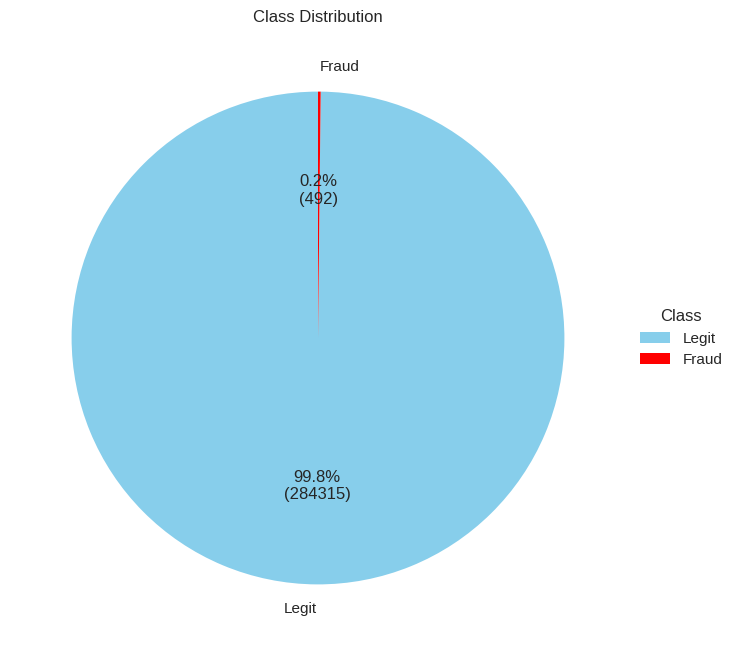

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use("seaborn-v0_8")
sns.set_context("notebook")

class_counts = df['Class'].value_counts()
class_ratios = df['Class'].value_counts(normalize=True)

def autopct_func(pct, allvals):
    absolute = int(pct/100.*np.sum(allvals))
    return f"{pct:.1f}%\n({absolute:d})"

plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels=['Legit', 'Fraud'], autopct=lambda pct: autopct_func(pct, class_counts), startangle=90, colors=['skyblue', 'red'])
plt.title("Class Distribution")
plt.legend(title="Class", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()

/tmp/ipykernel_447/2266068991.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Class', data=df, palette=['skyblue', 'red'])


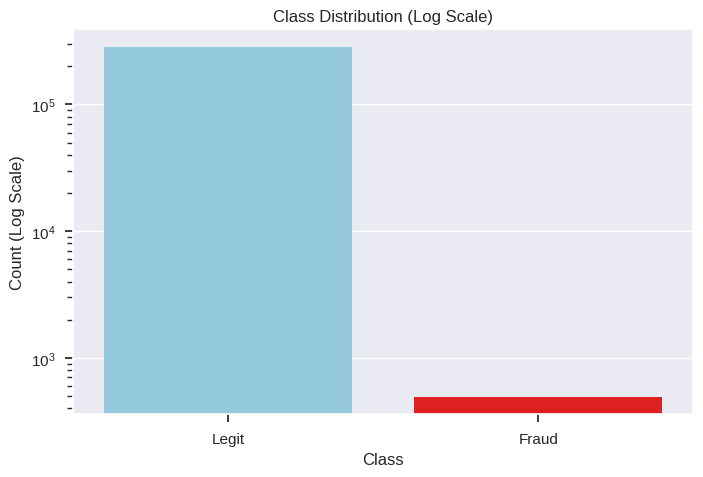

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Class', data=df, palette=['skyblue', 'red'])
ax.set_yscale("log") # This is the magic line
plt.title("Class Distribution (Log Scale)")
plt.xticks([0, 1], ['Legit', 'Fraud'])
plt.ylabel("Count (Log Scale)")
plt.show()

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


As we can see from the chart and the result of the command, there's a significant imbalance: a vast majority of transactions are legitimate (Class 0), while fraudulent transactions (Class 1) are extremely rare. This severe class imbalance is a critical challenge in fraud detection, as machine learning models can struggle to learn patterns from the minority class without specific handling techniques.

### Transaction Time Distribution Overview


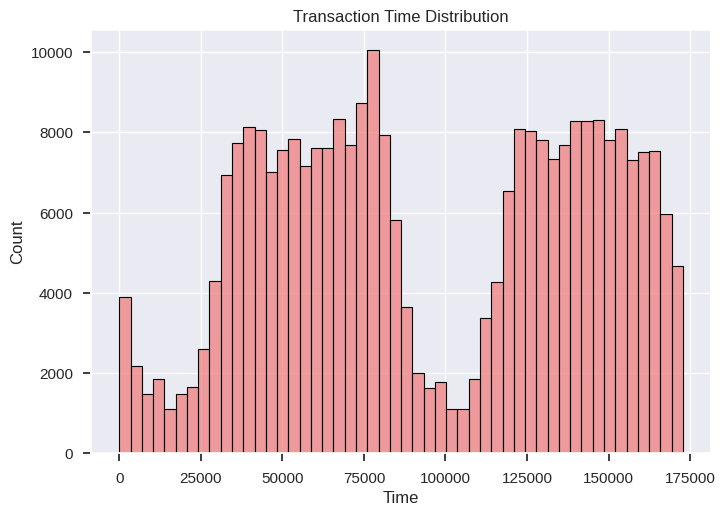

In [ ]:
sns.histplot(df['Time'], bins=50, color='lightcoral', edgecolor='black')
plt.title("Transaction Time Distribution")
plt.show()

This histogram shows the distribution of transaction times. The x-axis represents 'Time' (in seconds since the first transaction in the dataset), and the y-axis represents the count of transactions. We can observe distinct peaks and valleys in the transaction volume over time, possibly indicating daily cycles or periods of higher activity.

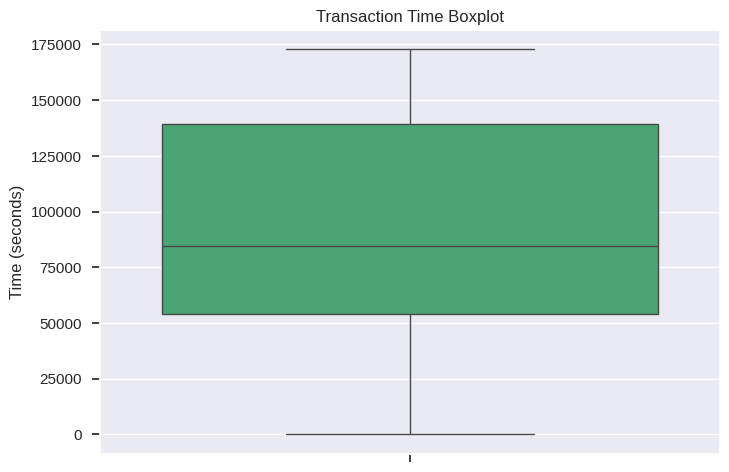

In [ ]:
sns.boxplot(y=df['Time'], color='mediumseagreen')
plt.title("Transaction Time Boxplot")
plt.ylabel("Time (seconds)")
plt.show()

### Transaction Time (in Hour) Distribution by Class

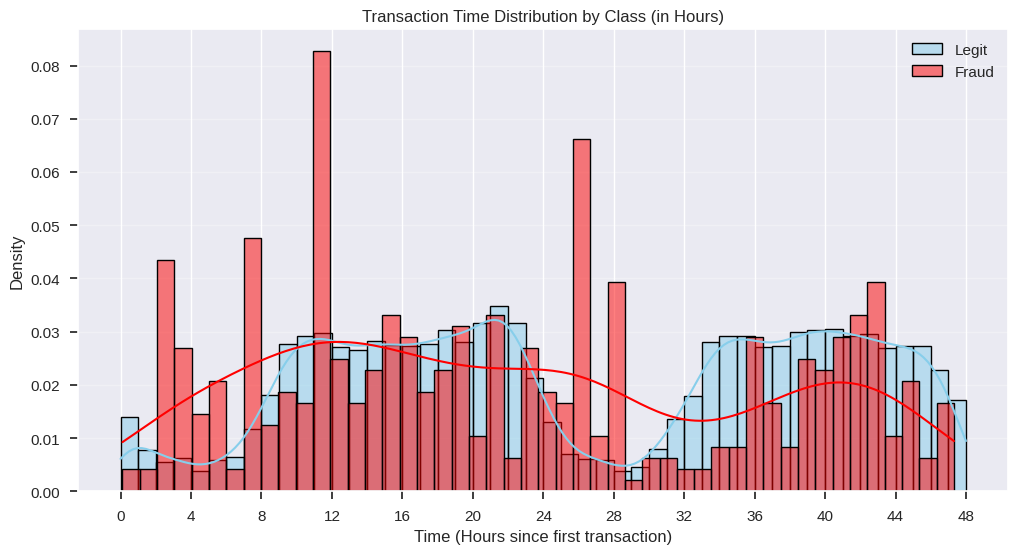

In [ ]:
plt.figure(figsize=(12, 6))

sns.histplot(df_legit_hours, color='skyblue', label='Legit', kde=True, stat='density', alpha=0.5, bins=48)
sns.histplot(df_fraud_hours, color='red', label='Fraud', kde=True, stat='density', alpha=0.5, bins=48)
plt.title('Transaction Time Distribution by Class (in Hours)')
plt.xlabel('Time (Hours since first transaction)')
plt.ylabel('Density')

plt.xticks(range(0, 52, 4))

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

We use this chart to scale the transaction time distribution by class of both Legit and Fraud. This chart shows:
- Legit transactions density follows a natural human rhythm. Significant "valleys" (low activity) occur roughly every 24 hours, representing a sleep period.
- Fraud transactions density shows no strong cyclical pattern. Fraudsters operate around the clock, including during "dead hours" when legitimate density is near zero.
- The tall red bars indicate concentrated bursts of fraud, likely automated attacks or batch processing, rather than individual human behavior.

### Fraud Occurrence Over Time Overview


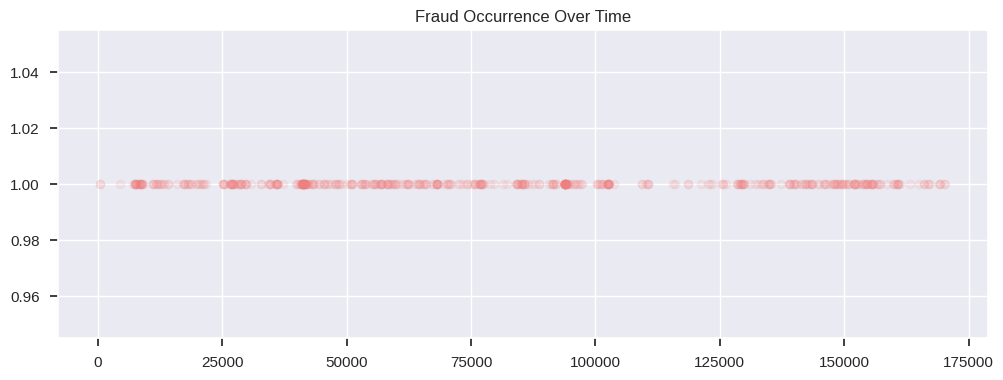

In [ ]:
plt.figure(figsize=(12,4))
plt.scatter(df_fraud['Time'], df_fraud['Class'], alpha=0.1, color='lightcoral')
plt.title("Fraud Occurrence Over Time")
plt.show()

This scatter plot visualizes the occurrence of fraudulent transactions against the transaction 'Time'. This plot helps to identify if fraudulent activities are concentrated during specific periods or if they are more spread out. No obvious large-scale temporal clusters of fraud are immediately apparent, but smaller patterns might exist.

### Transaction Amount Distribution & Log-Scaled Amount Distribution Overview


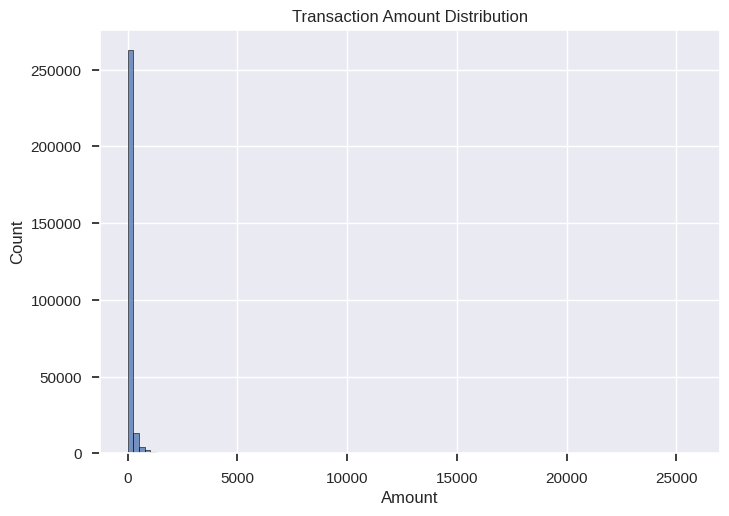

In [ ]:
sns.histplot(df['Amount'], bins=100)
plt.title("Transaction Amount Distribution")
plt.show()

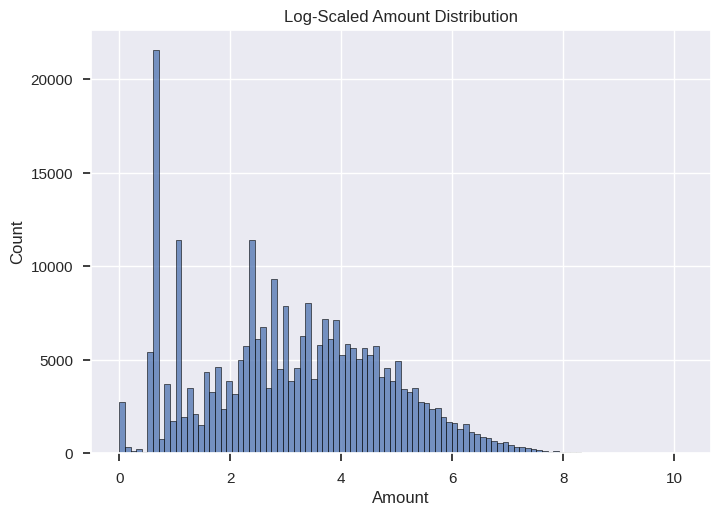

In [ ]:
sns.histplot(np.log1p(df['Amount']), bins=100)
plt.title("Log-Scaled Amount Distribution")
plt.show()

These two histograms display the distribution of transaction 'Amount'.

*   Transaction Amount Distribution: This first plot shows that most transactions involve small amounts, with a long tail extending to very large amounts. This indicates a highly skewed distribution.
*   Log-Scaled Amount Distribution: By applying a log transformation np.log1p to the 'Amount' feature, the second histogram reveals a more symmetrical, bell-shaped distribution. This transformation is often useful for features with highly skewed distributions, as it can help models learn more effectively from the data and reduce the impact of extreme outliers.

### Transaction Amount by Class Overview

/tmp/ipykernel_447/716958663.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, palette='viridis')


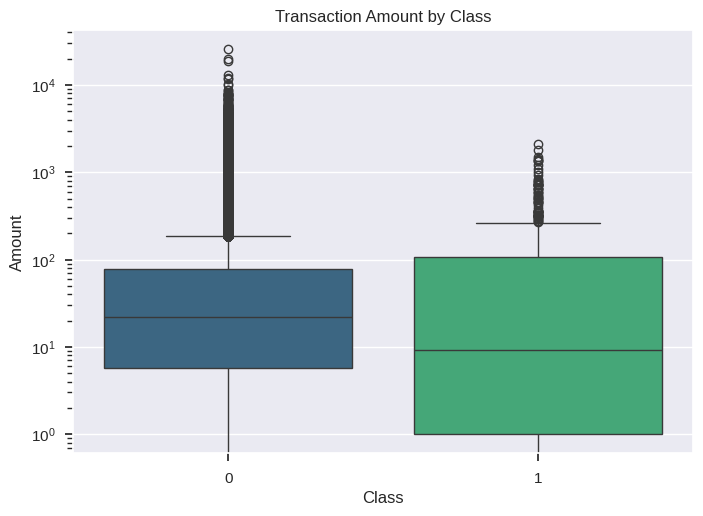

In [ ]:
sns.boxplot(x='Class', y='Amount', data=df, palette='viridis')
plt.yscale('log')
plt.title("Transaction Amount by Class")
plt.show()

This box plot (with a logarithmic y-axis) compares the distribution of transaction 'Amount' for legitimate (Class 0) and fraudulent (Class 1) transactions. From the box plot, we can see that the mean of fraud transactions is less than the mean of legit transactions. However, the upper quantile and lower quantiles of fraud transactions seem to be in a larger range compared to legit transactions upper and lower quantiles which can help us assume that a fraud transaction does not always have a large amount, it can start from a small amount.

### Feature Correlation with Class Overview

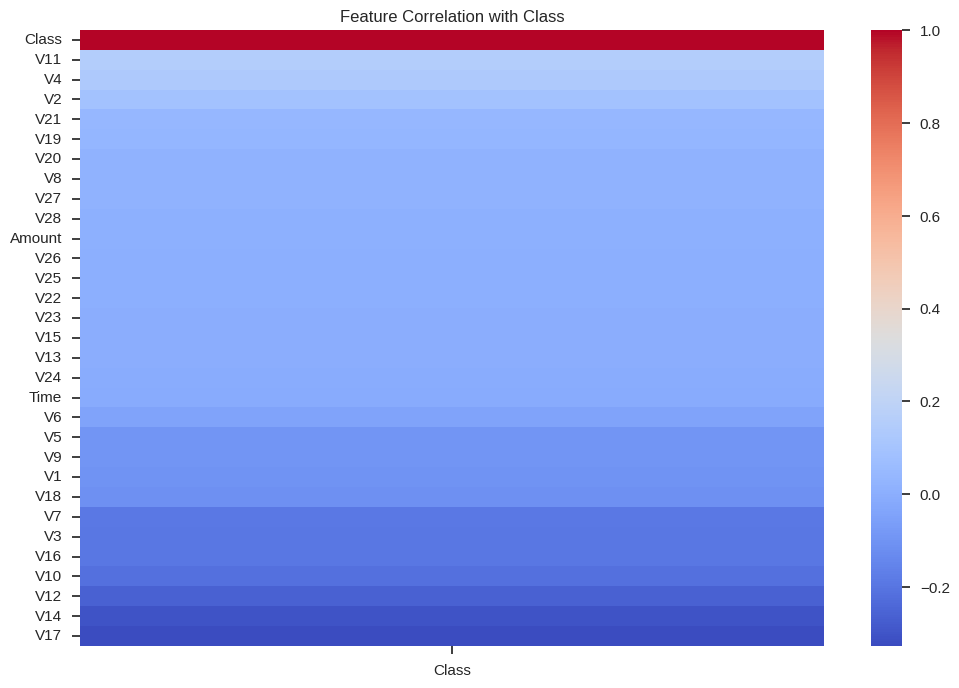

In [ ]:
corr = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr[['Class']].sort_values(by='Class', ascending=False),
            annot=False, cmap='coolwarm')
plt.title("Feature Correlation with Class")
plt.show()

This heatmap shows that there are not many correlation between the Class and other columns. From the heatmap, we can see that V17 is the most less correlated to Class, and V11 is the most correlated to Class.

In [ ]:
full_corr = df.corr()

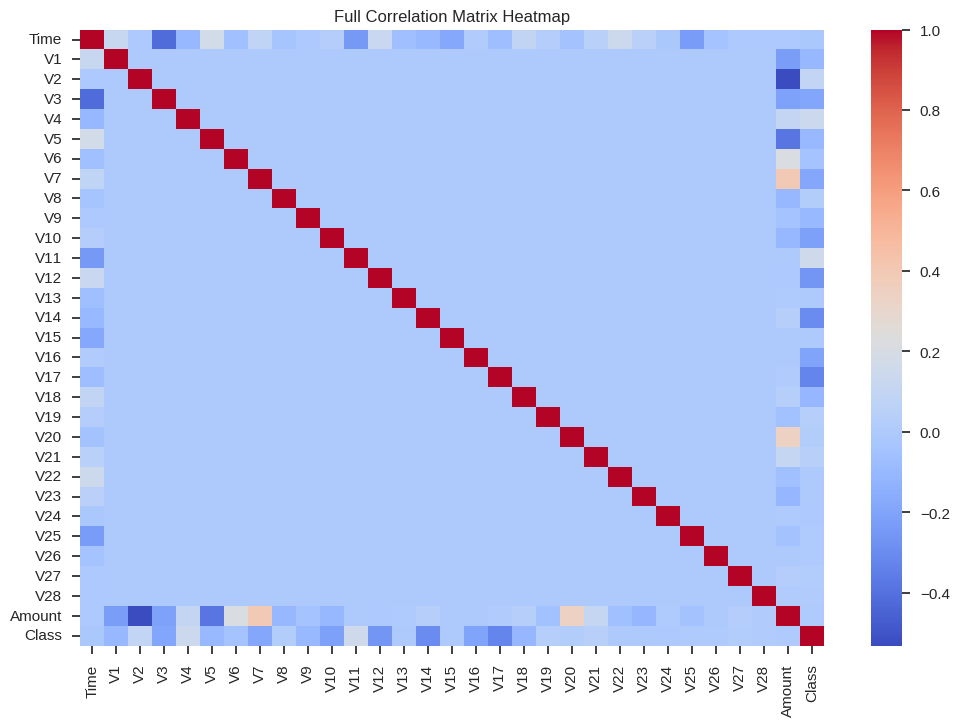

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(full_corr, annot=False, cmap='coolwarm')
plt.title("Full Correlation Matrix Heatmap")
plt.show()

Time and Amount exhibit some noticeble correlations with the V features

### Corr on fraud data
This is a fraud data so we won't consider about the correlation between Class and other V columns as the Class for this data is equal to 1. In this chart, we focus about the correlations between different V columns



In [ ]:
fraud_cor = df_fraud.corr()

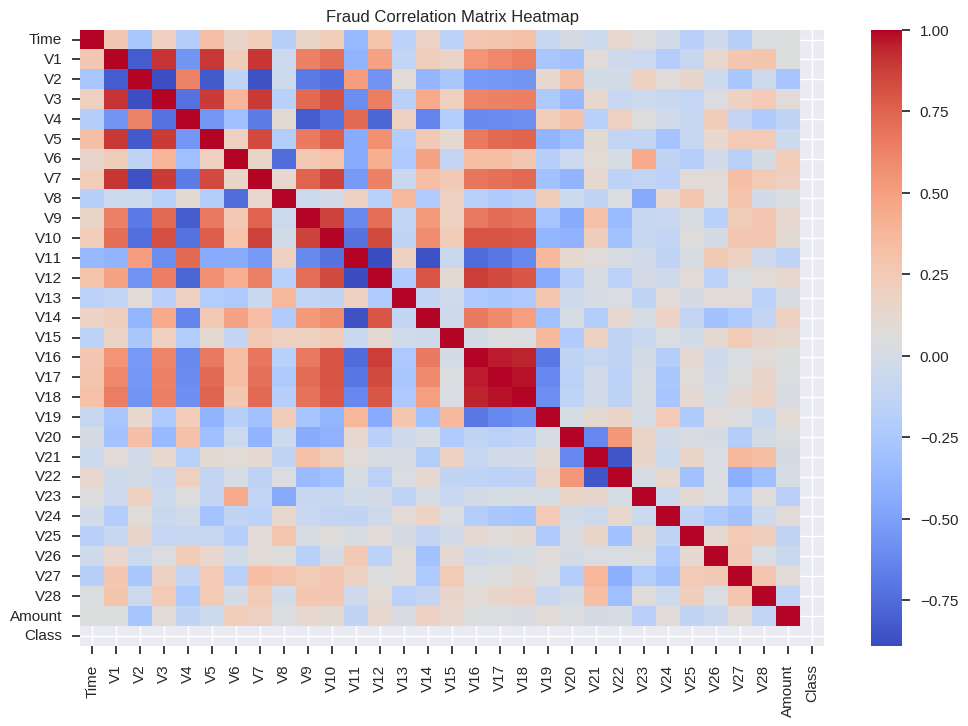

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(fraud_cor, annot=False, cmap='coolwarm')
plt.title("Fraud Correlation Matrix Heatmap")
plt.show()

On the fraud data, the correlations are clearer and significant:
- Features like V16, V17, and V18 show strong positive correlations with each other (the red square). We can consider to eliminate one or two of these features
- Feature V9 and V10 also show a strong posive correlation with each other
- (V9, V10) and (V16, 17, 18) show a strong positive correlation
- These features (at the edges) show very light colors compared to the V-features. This suggests that Amount and Time don't have a strong linear relationship with many of the anonymized V-features.

In general, features from V1 to V18 show a strong correlation between them. Features from V19 to V28 have slight correlations to all of the features.


### Corr on legit data

In [ ]:
legit_cor = df_legit.corr()

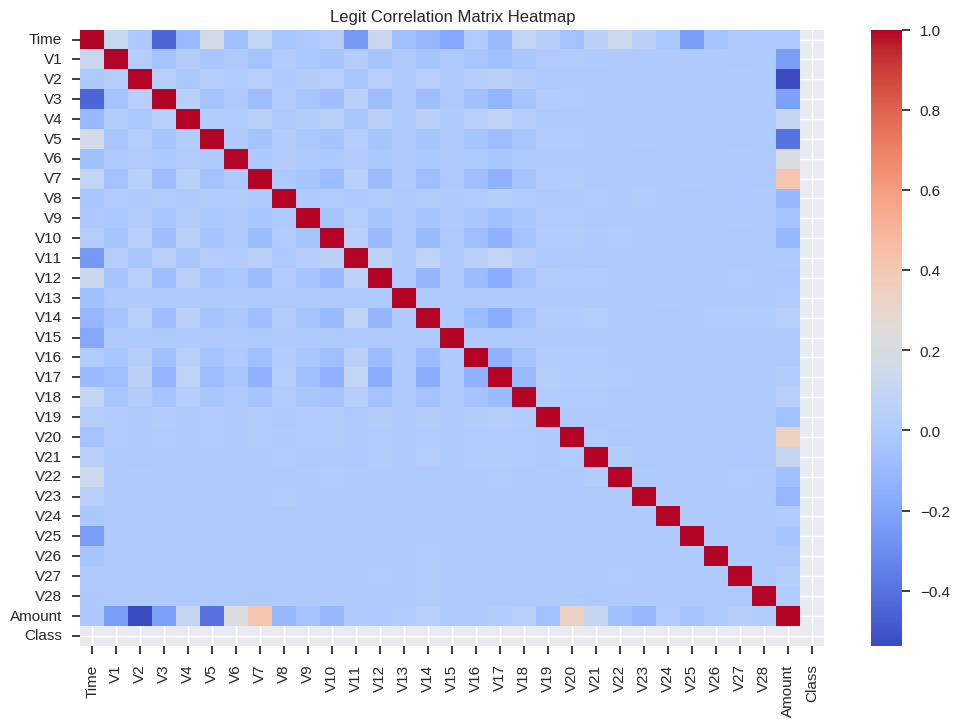

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(legit_cor, annot=False, cmap='coolwarm')
plt.title("Legit Correlation Matrix Heatmap")
plt.show()

In contrast, the correlation heat map for legit data has very few noticeable correlations.  

### Amount Outliers Overview


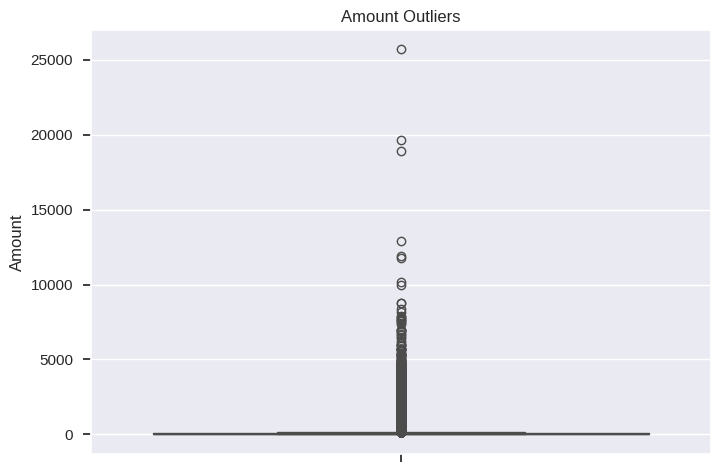

In [ ]:
sns.boxplot(y=df['Amount'])
plt.title("Amount Outliers")
plt.show()

This plot confirms the presence of many outliers in the 'Amount' feature, which is consistent with the skewed distribution observed in the histograms. Handling these outliers may be necessary for robust model performance.

### Time outlier overview

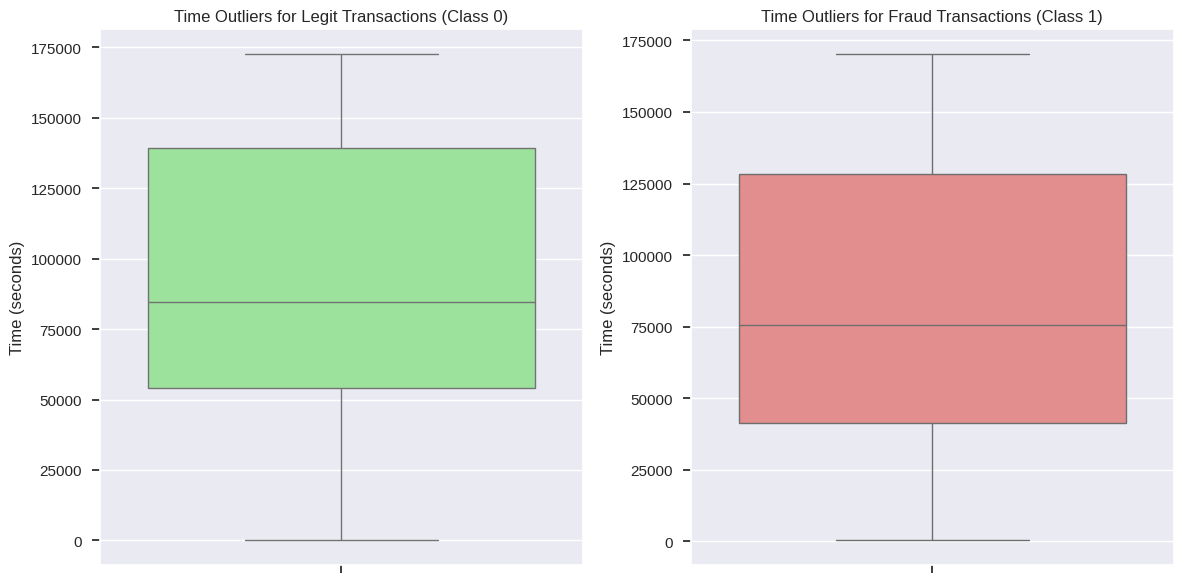

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_legit['Time'], color='lightgreen')
plt.title('Time Outliers for Legit Transactions (Class 0)')
plt.ylabel('Time (seconds)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_fraud['Time'], color='lightcoral')
plt.title('Time Outliers for Fraud Transactions (Class 1)')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

# Training and Evaluating Models

## Logistic Regression

### Trying with StandardScaler and no Feature selection

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (284807, 30)
Shape of y: (284807,)


In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

print("Pipeline created successfully with StandardScaler and LogisticRegression.")

Pipeline created successfully with StandardScaler and LogisticRegression.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (227845, 30)
Shape of X_test: (56962, 30)
Shape of y_train: (227845,)
Shape of y_test: (56962,)


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Value counts of y_resampled after SMOTE:")
print(y_resampled.value_counts())

Value counts of y_resampled after SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [ ]:
pipeline.fit(X_resampled, y_resampled)


Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(random_state=42, solver='liblinear'))])

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.16      0.91      0.27        98

    accuracy                           0.99     56962
   macro avg       0.58      0.95      0.63     56962
weighted avg       1.00      0.99      0.99     56962



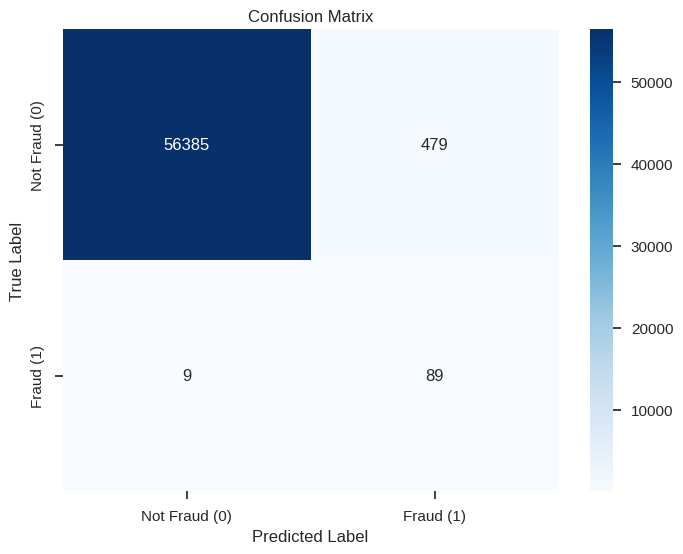

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = pipeline.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud (0)', 'Fraud (1)'],
            yticklabels=['Not Fraud (0)', 'Fraud (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Re-try with applying feature selections

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest

pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('sampler', SMOTE()),
    ('selector', SelectKBest(k=10)),
    ('classifier', LogisticRegression(solver='liblinear')) # Added solver='liblinear'
])


pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()), ('sampler', SMOTE()),
                ('selector', SelectKBest()),
                ('classifier', LogisticRegression(solver='liblinear'))])

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



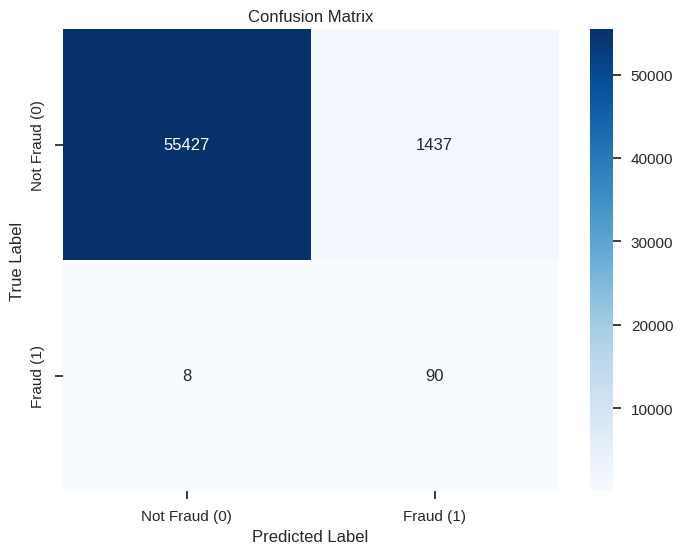

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = pipeline.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud (0)', 'Fraud (1)'],
            yticklabels=['Not Fraud (0)', 'Fraud (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

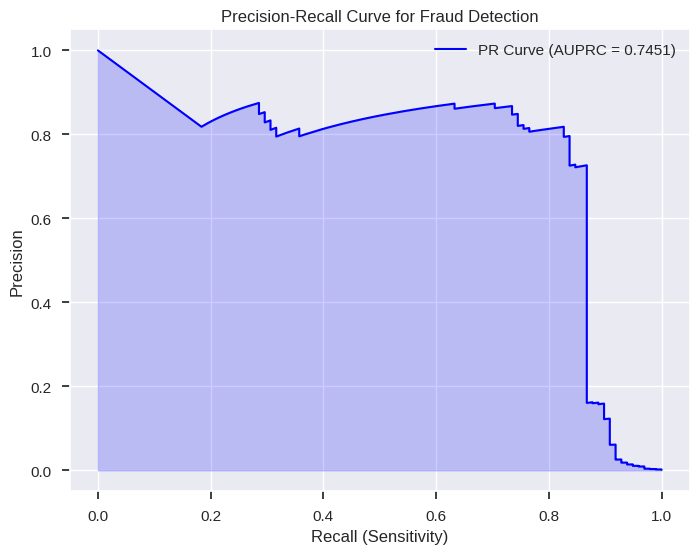

Area Under Precision-Recall Curve (AUPRC): 0.7451
Average Precision Score: 0.7296


In [ ]:
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

y_probs = pipeline.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
auprc_score = auc(recall, precision)
avg_precision = average_precision_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='b', label=f'PR Curve (AUPRC = {auprc_score:.4f})')
plt.fill_between(recall, precision, alpha=0.2, color='b')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Fraud Detection')
plt.legend(loc="upper right")
plt.grid(True)
plt.show()
print(f"Area Under Precision-Recall Curve (AUPRC): {auprc_score:.4f}")
print(f"Average Precision Score: {avg_precision:.4f}")

### Tuning with GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2']
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='precision',
    cv=5,
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best precision score found: ", grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters found:  {'classifier__C': 0.001, 'classifier__penalty': 'l1'}
Best precision score found:  0.06278876495858636


Classification Report for Best Model:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.91      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.98      0.99     56962



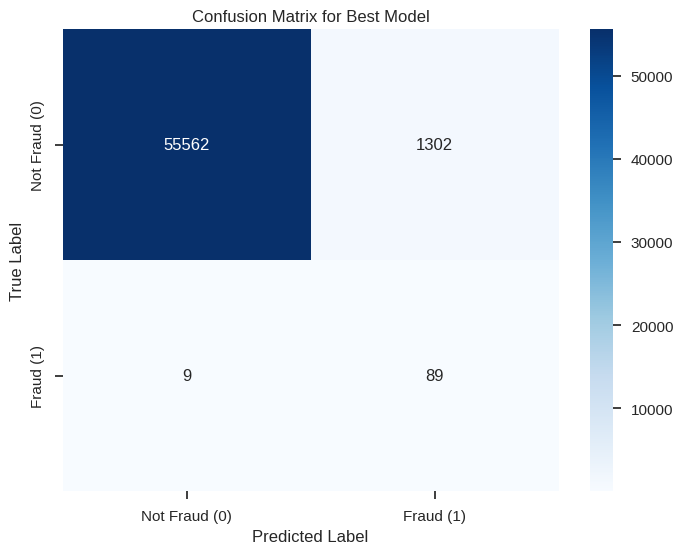

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc, average_precision_score
import seaborn as sns
import matplotlib.pyplot as plt

best_pipeline = grid_search.best_estimator_

y_pred = best_pipeline.predict(X_test)

print("Classification Report for Best Model:")
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud (0)', 'Fraud (1)'],
            yticklabels=['Not Fraud (0)', 'Fraud (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Best Model')
plt.show()


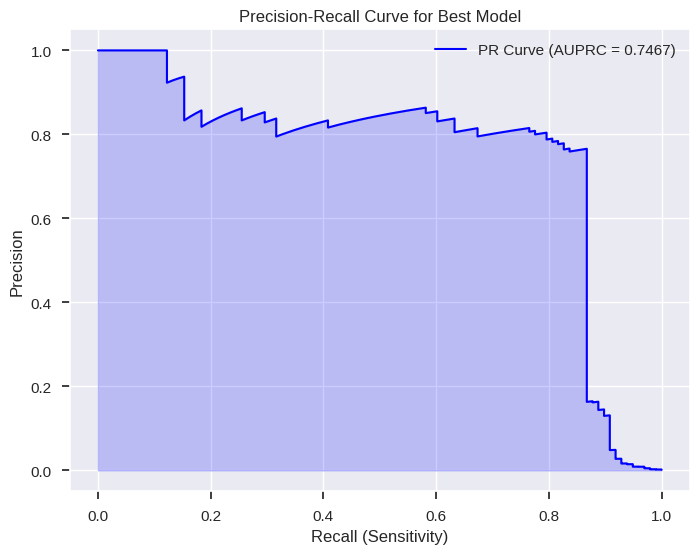

Area Under Precision-Recall Curve (AUPRC) for Best Model: 0.7467
Average Precision Score for Best Model: 0.7481


In [ ]:
# Calculate AUPRC
y_probs = best_pipeline.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
auprc_score = auc(recall, precision)
avg_precision = average_precision_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='b', label=f'PR Curve (AUPRC = {auprc_score:.4f})')
plt.fill_between(recall, precision, alpha=0.2, color='b')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Best Model')
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

print(f"Area Under Precision-Recall Curve (AUPRC) for Best Model: {auprc_score:.4f}")
print(f"Average Precision Score for Best Model: {avg_precision:.4f}")

While our baseline precision is 0.06 at a 0.5 threshold, the AUPRC curve shows that we have the potential to reach a Precision of 0.40 if we are willing to accept a Recall of 0.80 We tried to reduce the Recall just a little bit to have a better Precision, and we also adjusted the k value for selecting the best k features. However, the Precision for class 1 can’t increase a lot. Our highest pair of Precision and Recall was 0.06 and 0.92. This is still a good result because there will be 92% of fraud transactions detected, and there will be less than 2.5% of normal transactions that incorrectly are treated as fraud transactions.

### Tuning with optuna

In [ ]:
try:
    import optuna
except ImportError:
    print("Installing Optuna...")
    !pip install -q optuna
    import optuna

Installing Optuna...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.7 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def objective(trial):

    C = trial.suggest_float("C", 1e-4, 100, log=True)
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    k = trial.suggest_int("k", 5, 25)
    sampling_strategy = trial.suggest_float("sampling_strategy", 0.1, 0.5)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('sampler', SMOTE(
            sampling_strategy=sampling_strategy,
            random_state=42
        )),
        ('selector', SelectKBest(k=k)),
        ('classifier', LogisticRegression(
            C=C,
            penalty=penalty,
            solver='liblinear',   # supports l1 and l2
            class_weight=class_weight,
            max_iter=5000,
            random_state=42
        ))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="average_precision",
        n_jobs=-1
    )

    return scores.mean()

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best PR-AUC:", study.best_value)
print("Best Params:", study.best_params)

[I 2026-03-13 03:36:52,418] A new study created in memory with name: no-name-7a393360-e4b2-4a21-b0cf-cfaff271e8db
[I 2026-03-13 03:36:59,023] Trial 0 finished with value: 0.7385605174291341 and parameters: {'C': 1.668066164771906, 'penalty': 'l2', 'k': 6, 'sampling_strategy': 0.27526875523440597, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.7385605174291341.
[I 2026-03-13 03:37:08,230] Trial 1 finished with value: 0.7299783270201534 and parameters: {'C': 0.0011377166907587369, 'penalty': 'l1', 'k': 11, 'sampling_strategy': 0.42424337186381245, 'class_weight': None}. Best is trial 0 with value: 0.7385605174291341.
[I 2026-03-13 03:37:24,887] Trial 2 finished with value: 0.7458044822130931 and parameters: {'C': 0.7514603237272991, 'penalty': 'l2', 'k': 11, 'sampling_strategy': 0.3488952815426084, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.7458044822130931.
[I 2026-03-13 03:37:44,656] Trial 3 finished with value: 0.7499063610382704 and parameters: {'C': 1.775

Best PR-AUC: 0.7549433682007791
Best Params: {'C': 0.16087385810882682, 'penalty': 'l1', 'k': 20, 'sampling_strategy': 0.10159069009153304, 'class_weight': None}


In [ ]:
best_params = study.best_params

final_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('sampler', SMOTE(
        sampling_strategy=best_params["sampling_strategy"],
        random_state=42
    )),
    ('selector', SelectKBest(k=best_params["k"])),
    ('classifier', LogisticRegression(
        C=best_params["C"],
        penalty=best_params["penalty"],
        solver='liblinear',
        class_weight=best_params["class_weight"],
        max_iter=5000,
        random_state=42
    ))
])

final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('sampler',
                 SMOTE(random_state=42, sampling_strategy=0.10159069009153304)),
                ('selector', SelectKBest(k=20)),
                ('classifier',
                 LogisticRegression(C=0.16087385810882682, max_iter=5000,
                                    penalty='l1', random_state=42,
                                    solver='liblinear'))])

In [ ]:
y_proba = final_pipeline.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Choose threshold that maximizes F1
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best threshold:", best_threshold)

Best threshold: 0.9164725229093095


In [ ]:
y_pred_optimal = (y_proba >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_optimal))

print("Test PR-AUC:",
      average_precision_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.80      0.82      0.81        98

    accuracy                           1.00     56962
   macro avg       0.90      0.91      0.90     56962
weighted avg       1.00      1.00      1.00     56962

Test PR-AUC: 0.761830751454498


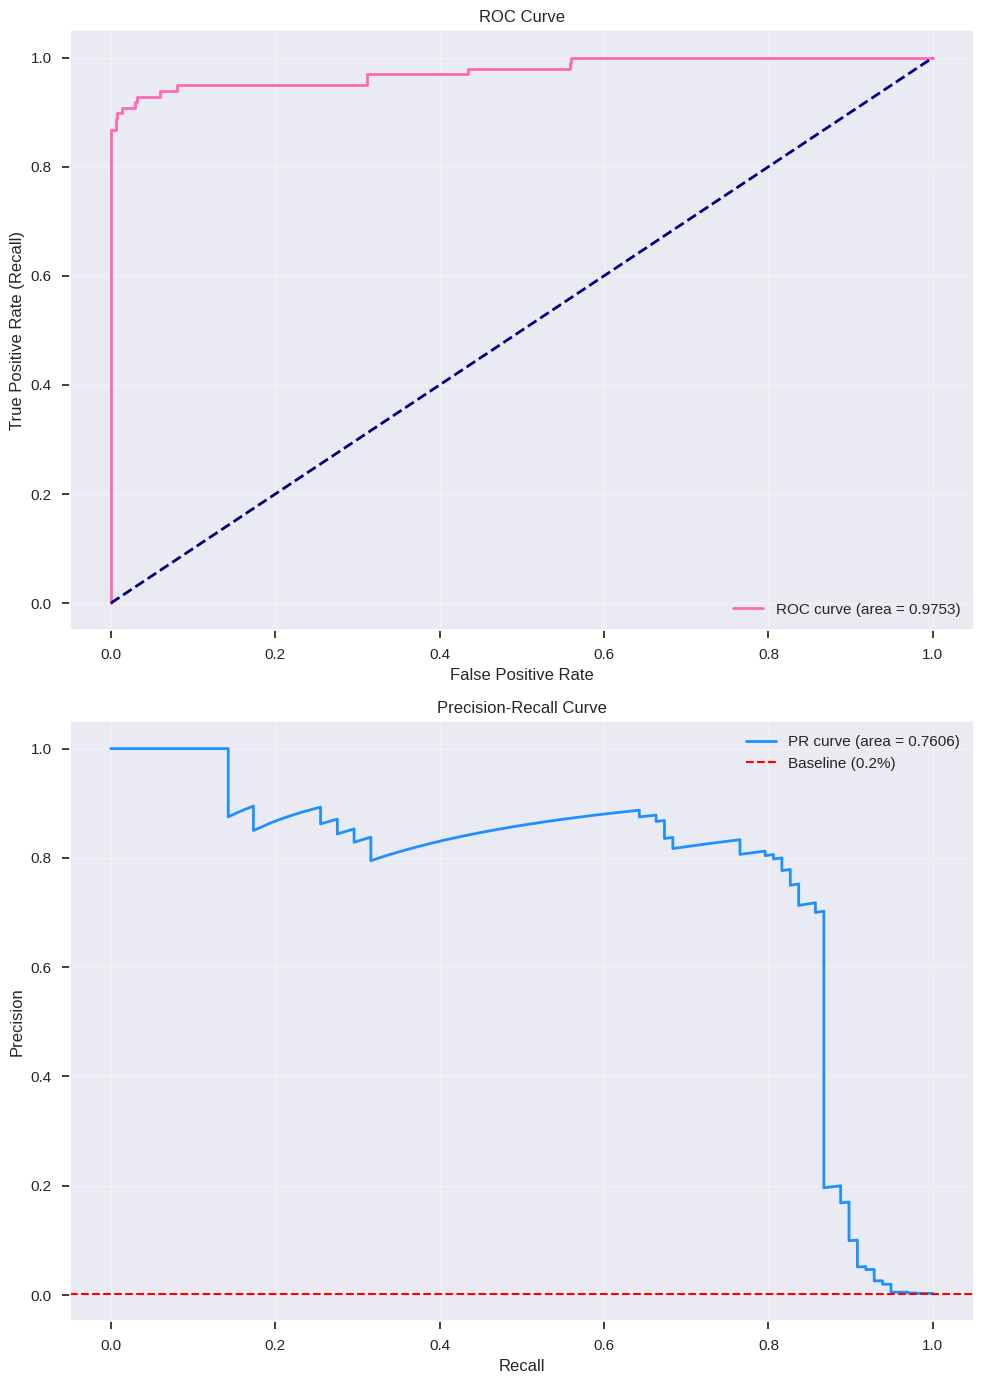

{'Model': 'Logistic Regression', 'ROC AUC': np.float64(0.9752574707429399), 'PR AUC': np.float64(0.760558081770919), 'F1-score': 0.8080808080808081, 'Precision': 0.8, 'Recall': 0.8163265306122449, 'False Positive Rate': np.float64(0.00035171637591446255)}


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, f1_score

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

y_pred_optimal = (y_proba >= best_threshold).astype(int)
f1 = f1_score(y_test, y_pred_optimal, pos_label=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 14)) # Increased height for stacking

ax1.plot(fpr, tpr, color='hotpink', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_title('ROC Curve')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

ax2.plot(recall, precision, color='dodgerblue', lw=2, label=f'PR curve (area = {pr_auc:.4f})')
ax2.axhline(y=0.0017, color='red', linestyle='--', label='Baseline (0.2%)')
ax2.set_title('Precision-Recall Curve')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc="upper right")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

from sklearn.metrics import precision_score, recall_score, confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_optimal).ravel()

# FPR = FP / (FP + TN)
final_fpr = fp / (fp + tn)

log_results = {
    'Model': 'Logistic Regression',
    'ROC AUC': roc_auc,
    'PR AUC': pr_auc,
    'F1-score': f1,
    'Precision': precision_score(y_test, y_pred_optimal),
    'Recall': recall_score(y_test, y_pred_optimal),
    'False Positive Rate': final_fpr
}

print(log_results)

## Random Forest


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("amount_scaler", StandardScaler(), ["Amount"])
    ],
    remainder="passthrough"
)

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('amount_scaler',
                                                  StandardScaler(),
                                                  ['Amount'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

### Make predictions and Evaluate Pipeline

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Predictions
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

# ROC AUC
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC AUC Score:", roc_auc)


[[56861     3]
 [   25    73]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.9529168413285405


### Plot ROC curve for Random Forest

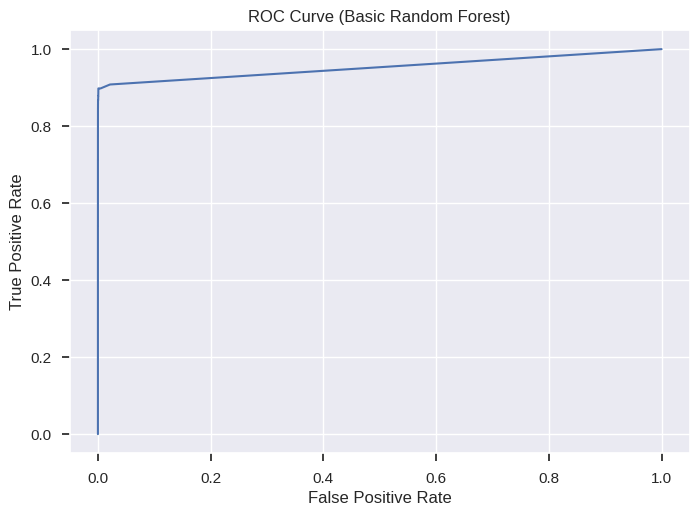

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Basic Random Forest)")
plt.show()

### Use feature selection with random forest

In [ ]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# Feature selector (uses RF importance)
feature_selector = SelectFromModel(
    RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    threshold="median"
)

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("feature_selection", feature_selector),
    ("model", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('amount_scaler',
                                                  StandardScaler(),
                                                  ['Amount'])])),
                ('feature_selection',
                 SelectFromModel(estimator=RandomForestClassifier(n_jobs=-1,
                                                                  random_state=42),
                                 threshold='median')),
                ('model',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

In [ ]:
from sklearn.metrics import average_precision_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]
print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC AUC Score:", roc_auc)

pr_auc = average_precision_score(y_test, y_proba)
print("PR AUC:", pr_auc)

[[56861     3]
 [   22    76]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.78      0.86        98

    accuracy                           1.00     56962
   macro avg       0.98      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.9479948757077395
PR AUC: 0.8497920550801098


### Use SMOTE with random forest for better class imbalance handling

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),

    # Apply SMOTE AFTER preprocessing
    ("smote", SMOTE(
        sampling_strategy=0.2,   # minority becomes 20% of majority
        random_state=42,
    )),

    # Feature selection
    ("feature_selection", SelectFromModel(
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ),
        threshold="median"
    )),

    # Final classifier
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('amount_scaler',
                                                  StandardScaler(),
                                                  ['Amount'])])),
                ('smote', SMOTE(random_state=42, sampling_strategy=0.2)),
                ('feature_selection',
                 SelectFromModel(estimator=RandomForestClassifier(n_jobs=-1,
                                                                  random_state=42),
                                 threshold='median')),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [ ]:
from sklearn.metrics import average_precision_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Predictions
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

# ROC AUC
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC AUC Score:", roc_auc)

pr_auc = average_precision_score(y_test, y_proba)
print("PR AUC:", pr_auc)

[[56845    19]
 [   14    84]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.86      0.84        98

    accuracy                           1.00     56962
   macro avg       0.91      0.93      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.983087736008866
PR AUC: 0.8669734404500001


### Tune with RandomizedSearchCV

In [ ]:
param_dist = {

    # SMOTE
    "smote__sampling_strategy": [0.1, 0.25, 0.5],

    # Feature Selection threshold
    "feature_selection__threshold": ["mean", "median"],

    # Random Forest hyperparameters
    "model__n_estimators": [100, 110, 120, 130],
    "model__max_depth": [10],
    "model__min_samples_split": [2, 5],
    "model__max_features": ["sqrt", "log2"]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=2,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=5,
    scoring="average_precision",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 2 folds for each of 5 candidates, totalling 10 fits


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


RandomizedSearchCV(cv=StratifiedKFold(n_splits=2, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('amount_scaler',
                                                                               StandardScaler(),
                                                                               ['Amount'])])),
                                             ('smote',
                                              SMOTE(random_state=42,
                                                    sampling_strategy=0.2)),
                                             ('feature_selection',
                                              SelectFromModel(estimator=RandomForestClassifie...
                                                                     n_jobs=-1,
                                                                     random_state=42))]),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'feature_selection__threshold': ['mean',
                                                                         'median'],
                                        'model__max_depth': [10],
                                        'model__max_features': ['sqrt', 'log2'],
                                        'model__min_samples_split': [2, 5],
                                        'model__n_estimators': [100, 110, 120,
                                                                130],
                                        'smote__sampling_strategy': [0.1, 0.25,
                                                                     0.5]},
                   random_state=42, scoring='average_precision', verbose=2)

In [ ]:
print("Best Params:")
print(random_search.best_params_)

print("\nBest CV PR-AUC:")
print(random_search.best_score_)

Best Params:
{'smote__sampling_strategy': 0.25, 'model__n_estimators': 130, 'model__min_samples_split': 5, 'model__max_features': 'log2', 'model__max_depth': 10, 'feature_selection__threshold': 'median'}

Best CV PR-AUC:
0.7957104488609641


In [ ]:
best_model_rf = random_search.best_estimator_

y_pred_rf = best_model_rf.predict(X_test)
y_proba_rf = best_model_rf.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, precision_score, recall_score, f1_score

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
pr_auc_rf = average_precision_score(y_test, y_proba_rf)
precision_rf = precision_score(y_test, y_pred_rf, pos_label=1)
recall_rf = recall_score(y_test, y_pred_rf, pos_label=1)
f1_rf = f1_score(y_test, y_pred_rf, pos_label=1)

print("ROC AUC:", roc_auc_rf)
print("PR AUC:", pr_auc_rf)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
fpr_rf = fp / (fp + tn)

rf_results = {
    'Model': 'Random Forest',
    'ROC AUC': roc_auc_rf,
    'PR AUC': pr_auc_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1-score': f1_rf,
    'False Positive Rate': fpr_rf
}

[[56746   118]
 [   11    87]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.42      0.89      0.57        98

    accuracy                           1.00     56962
   macro avg       0.71      0.94      0.79     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.9777145505782504
PR AUC: 0.8205912451645644


## XGBoost without SMOTE

In [ ]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
import numpy as np

neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)

scale_pos_weight = neg / pos
print(scale_pos_weight)

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

pipeline.fit(X_train, y_train)

y_proba = pipeline.predict_proba(X_test)[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("PR AUC:", average_precision_score(y_test, y_proba))

577.2868020304569


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:39:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC AUC: 0.9652209927302379
PR AUC: 0.8751687433653755


### XGBoost with SMOTE

In [ ]:
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
    ))
])

pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:39:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('amount_scaler',
                                                  StandardScaler(),
                                                  ['Amount'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [ ]:
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("PR AUC:", average_precision_score(y_test, y_proba))

ROC AUC: 0.9652209927302379
PR AUC: 0.8751687433653755


In [ ]:
y_proba = pipeline.predict_proba(X_test)[:, 1]

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=30,
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
    verbose=2
)

# RandomizedSearchCV to tune hyperparameters

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
param_dist = {
    "model__n_estimators": [300, 500, 700],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__gamma": [0, 0.1, 0.3],
    "model__min_child_weight": [1, 3, 5]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=15,
    scoring="average_precision",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:54:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('amount_scaler',
                                                                               StandardScaler(),
                                                                               ['Amount'])])),
                                             ('smote', SMOTE(random_state=42)),
                                             ('model',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,...
                                                            num_parallel_tree=None, ...))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    1.0],
                                        'model__gamma': [0, 0.1, 0.3],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 4, 5, 6],
                                        'model__min_child_weight': [1, 3, 5],
                                        'model__n_estimators': [300, 500, 700],
                                        'model__subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='average_precision', verbose=2)

# Evaluate after tuning

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

best_model_xgb = random_search.best_estimator_

y_proba_xgb = best_model_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = best_model_xgb.predict(X_test)

roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
pr_auc_xgb = average_precision_score(y_test, y_proba_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, pos_label=1)
recall_xgb = recall_score(y_test, y_pred_xgb, pos_label=1)
f1_xgb = f1_score(y_test, y_pred_xgb, pos_label=1)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_xgb).ravel()
fpr_xgb = fp / (fp + tn)
print("ROC AUC:", roc_auc_xgb)
print("PR AUC:", pr_auc_xgb)

xg_results = {
    'Model': 'XGBoost',
    'ROC AUC': roc_auc_xgb,
    'PR AUC': pr_auc_xgb,
    'Precision': precision_xgb,
    'Recall': recall_xgb,
    'F1-score': f1_xgb,
    'False Positive Rate': fpr_xgb
}

ROC AUC: 0.9835310601449359
PR AUC: 0.8732480538196923


# Compare Model Evaluation Results

In [ ]:
all_results = [
    log_results,

    rf_results,
    xg_results
]

comparison_df = pd.DataFrame(all_results)

comparison_df = comparison_df.sort_values(by='F1-score', ascending=False)
display(comparison_df)

,Model,ROC AUC,PR AUC,F1-score,Precision,Recall,False Positive Rate
0,Logistic Regression,0.975257,0.760558,0.808081,0.800000,0.816327,0.000352
2,XGBoost,0.983531,0.873248,0.807692,0.763636,0.857143,0.000457
1,Random Forest,0.977715,0.820591,0.574257,0.424390,0.887755,0.002075


Our primary goal was to achieve a Recall >=  0.85 and an AUPRC >=  0.80 while
keeping the False Positive Rate <=  0.1%. Both the XGBoost and Random Forest
models met the recall target, but XGBoost is the superior choice for deployment as it
satisfies all three measurable success criteria simultaneously.

# Our key-findings and Summary

## Key-findings
- Feature Utility Analysis revealed that the "Amount" feature was less predictive
than PCA components, largely because the range of values for both legitimate
and fraudulent classes overlapped significantly.
- SMOTE Resampling proved essential in balancing the 0.17% minority class,
enabling models to learn fraud patterns that were otherwise hidden.
- XGBoost delivered the best overall performance, achieving an AUPRC of 0.873
and a Recall of 0.857, successfully meeting all specified business success
criteria.
29
- Operational feasibility was confirmed by keeping the False Positive Rate (FPR) at
0.045%, ensuring a frictionless experience for 99.9% of honest customers.

## Summary
Our goal was to create a machine learning model that could be used by a financial
institution, such as a bank, to detect fraudulent transactions. We started with a
dataset that was highly imbalanced with only 0.17% of transactions being
fraudulent. The goal was to be able to find as many of the fraudulent transactions
as possible without falsly identifying too many of the legitimate transactions.
After creating pipelines using logistic regression, random forest, and XGBoost, we
found that XGBoost performed the best and was closest to what could be used
by a bank.
Banks are typically able to detect 80-90+ percent of fraudulent transactions. They
also want the precision to be around 50 percent. [2] Based on those goals, our
model is in the ballpark of what could be used in real life. However, we started
with a clean dataset, and it would most likely take more work with a bank that has
more, less clean data.